<a href="https://colab.research.google.com/github/tainabh/analise_titanic/blob/main/analise_titanic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [464]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**ANÁLISE EXPLORATÓRIA DE DADOS DO TITANIC**

A presente análise exploratória tem como objetivo compreender o comportamento geral dos dados do conjunto Titanic, identificando padrões, relações entre variáveis e possíveis fatores associados à sobrevivência dos passageiros.

A partir da exploração do dataset, serão realizadas etapas de importação, organização e tratamento dos dados, além da geração de estatísticas descritivas e visualizações gráficas.

**Perguntas a serem respondidas na análise:**

1. Qual é a proporção de passageiros que sobreviveram ao naufrágio?
2. Existe relação entre a classe do passageiro e a probabilidade de sobrevivência?
3. O gênero do passageiro influenciou nas chances de sobrevivência?
4. A idade teve impacto na probabilidade de sobrevivência?
5. O tamanho da família a bordo apresenta alguma relação com a sobrevivência?
6. O valor pago pela passagem influenciou na chance de sobrevivência?
7. O porto de embarque teve alguma influência na sobrevivência dos passageiros?

A partir dessas análises, busca-se obter insights que ajudem a compreender melhor os fatores que podem ter influenciado a sobrevivência dos passageiros do Titanic.

# 1. IMPORTANDO A BIBLIOTECA PANDAS

In [465]:
import pandas as pd

# 2. CARREGAMENTO DOS DADOS

In [466]:
df_titanic = pd.read_csv('/titanic_dataset.csv')


# Verificando as linhas iniciais da tabela
df_titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [467]:
# Verificando as últimas linhas da tabela

df_titanic.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


# 3.  ANÁLISES GERAIS ANTES DO TRATAMENTO E LIMPEZA DOS DADOS

In [468]:
# Analisando amostra aleatória

df_titanic.sample()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
153,154,0,3,"van Billiard, Mr. Austin Blyler",male,40.5,0,2,A/5. 851,14.5,NaN,S


In [469]:
# Analisando as informações

df_titanic.info()

# 891 passageiros à bordo

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [470]:
# Descrevendo as informações

df_titanic.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


# 4. TRATAMENTO E LIMPEZA INICIAL DOS DADOS

In [471]:
# Verificando a existência de linhas duplicadas

total_duplicadas = df_titanic.duplicated().sum()
total_duplicadas


np.int64(0)

In [472]:

# Traduzindo as colunas

map_titanic = {
    'PassengerId': 'id_passageiro',
    'Survived': 'sobrevivente',
    'Pclass': 'classe',
    'Name': 'nome',
    'Sex': 'genero',
    'Age': 'idade',
    'SibSp': 'qtd_irmaos_conjuges',
    'Parch': 'qtd_pais_filhos',
    'Ticket': 'bilhete',
    'Fare': 'preco_passagem',
    'Cabin': 'cabine',
    'Embarked': 'porto_embarque'
}

# Aplicando as renomeações

df_titanic.rename(columns=map_titanic, inplace=True)
print ("Colunas traduzidas para o português.")


Colunas traduzidas para o português.


In [473]:
# Mantendo a coluna "sobrevivente", já que está em formato de número inteiro, e criando uma nova coluna com nome "sobreviveu" atribuindo as variáveis para "sim" ou "não" no formato string


df_titanic['sobreviveu'] = df_titanic['sobrevivente'].map({0: 'Não', 1: 'Sim'})

df_titanic['sobreviveu'].value_counts()



,count
sobreviveu,
Não,549
Sim,342


In [474]:
# A coluna "classe" será mantida

df_titanic['classe']. value_counts ()

,count
classe,
3,491
1,216
2,184


In [475]:
# A coluna nome será removida do conjunto de dados a fim de preservar a identidade dos passageiros, evitando a exposição de informações individuais que não são necessárias para a análise.

df_titanic=df_titanic.drop(columns=['nome'])


In [476]:
# Transformando a coluna "gênero"

df_titanic['genero'] = df_titanic['genero'].map({'male': 'Masculino', 'female': 'Feminino'})


In [477]:
# A coluna "idade" apresenta 177 valores ausentes. Como a remoção dessas linhas resultaria em uma perda significativa de dados, optou-se por manter os valores NaN. Além disso, a coluna foi mantida no tipo float64, pois esse formato permite a realização de operações estatísticas e cálculos mesmo na presença de valores ausentes, sem comprometer as análises.


In [478]:
# Criando a coluna "tamanho_familia" com base nas colunas "qtd_irmaos_conjuges" e "qtd_pais_filhos", somando o próprio passageiro
df_titanic['tamanho_familia'] = df_titanic['qtd_irmaos_conjuges'] + df_titanic['qtd_pais_filhos'] + 1

# Removendo as colunas originais para limpeza de dados

df_titanic=df_titanic.drop(columns=['qtd_irmaos_conjuges', 'qtd_pais_filhos'])


In [479]:
# A coluna "bilhete" será removida por não ter relevância nas análises estatísticas a serem realizadas no momento.

df_titanic = df_titanic.drop(columns=['bilhete'])

In [480]:
# A coluna "preco_passagem" será mantida.



In [481]:
# A coluna cabine possui informações em apenas 204 registros do conjunto de dados. Devido à grande quantidade de valores ausentes, optou-se pela exclusão dessa coluna, pois sua manutenção poderia comprometer a qualidade das análises.

df_titanic = df_titanic.drop(columns=['cabine'])

In [482]:
# A coluna "porto_embarque" apresenta 2 valores ausentes. Como a quantidade de registros faltantes é pequena, optou-se por manter a coluna e substituir os valores ausentes pela categoria “informação não obtida”.

df_titanic['porto_embarque'] = df_titanic['porto_embarque'].fillna('Informação não obtida')

df_titanic['porto_embarque']. value_counts ()

,count
porto_embarque,
S,644
C,168
Q,77
Informação não obtida,2


In [483]:
# Versão final da tabela após tratamento e limpeza dos dados

df_titanic.head()

,id_passageiro,sobrevivente,classe,genero,idade,preco_passagem,porto_embarque,sobreviveu,tamanho_familia
0,1,0,3,Masculino,22.0,7.2500,S,Não,2
1,2,1,1,Feminino,38.0,71.2833,C,Sim,2
2,3,1,3,Feminino,26.0,7.9250,S,Sim,1
3,4,1,1,Feminino,35.0,53.1000,S,Sim,2
4,5,0,3,Masculino,35.0,8.0500,S,Não,1


# 5. ANÁLISE DO CONJUNTO DE DADOS

sobrevivente
0    61.616162
1    38.383838
Name: proportion, dtype: float64


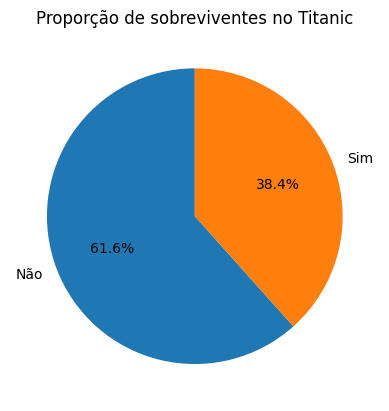

In [484]:
# Verificando a proporção de passageiros que sobreviveram ao naufrágio

proporcao = df_titanic['sobrevivente'].value_counts(normalize=True) * 100
print(proporcao)

import matplotlib.pyplot as plt

df_titanic['sobreviveu'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90,
    ylabel=''
)

plt.title('Proporção de sobreviventes no Titanic')
plt.show()

# A análise da proporção de sobreviventes indica que a maioria dos passageiros não sobreviveu ao naufrágio do Titanic. Aproximadamente 62% dos passageiros morreram, enquanto cerca de 38% conseguiram sobreviver. Esse resultado evidencia a dimensão da tragédia e serve como ponto de partida para investigar quais fatores podem ter influenciado as chances de sobrevivência, como classe, sexo, idade e outras características dos passageiros.


sobreviveu        Não        Sim
classe                          
1           37.037037  62.962963
2           52.717391  47.282609
3           75.763747  24.236253


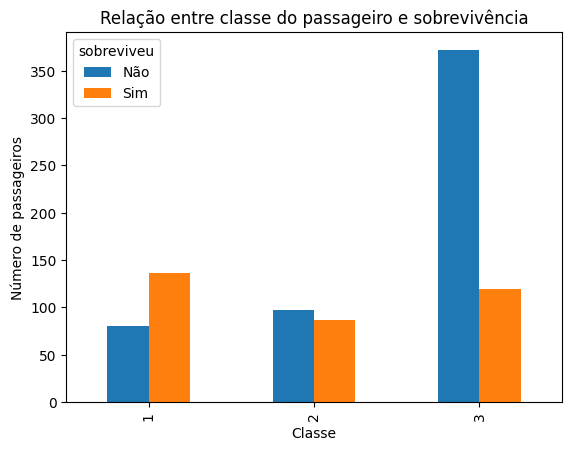

In [485]:
# Análise da relação entre a classe do passageiro e a probabilidade de sobrevivência

relacao_classe_sobrevivencia = pd.crosstab(df_titanic['classe'], df_titanic['sobreviveu'], normalize='index') * 100
print(relacao_classe_sobrevivencia)

pd.crosstab(df_titanic['classe'], df_titanic['sobreviveu']).plot(kind='bar')

plt.title('Relação entre classe do passageiro e sobrevivência')
plt.xlabel('Classe')
plt.ylabel('Número de passageiros')
plt.show()

# A análise da relação entre a classe do passageiro e a sobrevivência indica que passageiros das classes mais altas apresentaram maiores taxas de sobrevivência. Isso sugere que fatores socioeconômicos e a localização das cabines no navio podem ter influenciado as chances de resgate durante o naufrágio.


sobreviveu        Não        Sim
genero                          
Feminino    25.796178  74.203822
Masculino   81.109185  18.890815


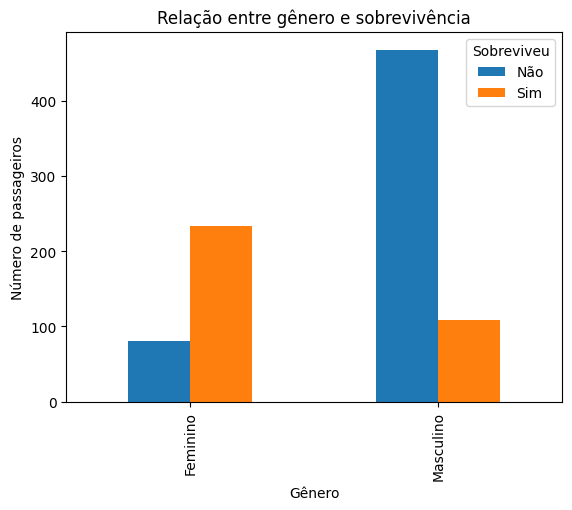

In [486]:
# Relação entre o gênero do passageiro e a probabilidade de sobrevivência

relacao_genero_sobrevivencia = pd.crosstab(df_titanic['genero'], df_titanic['sobreviveu'], normalize='index') * 100
print(relacao_genero_sobrevivencia)

import matplotlib.pyplot as plt

pd.crosstab(df_titanic['genero'], df_titanic['sobreviveu']).plot(kind='bar')

plt.title('Relação entre gênero e sobrevivência')
plt.xlabel('Gênero')
plt.ylabel('Número de passageiros')
plt.legend(title='Sobreviveu')
plt.show()

# A análise indica uma forte relação entre o gênero do passageiro e a sobrevivência. Passageiras do sexo feminino apresentaram uma taxa de sobrevivência significativamente maior do que passageiros do sexo masculino, o que pode estar relacionado ao protocolo de evacuação adotado na época, conhecido como “mulheres e crianças primeiro”.

/tmp/ipykernel_714/1850759517.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_titanic.groupby('faixa_etaria')['sobreviveu'].value_counts(normalize=True).unstack()*100
/tmp/ipykernel_714/1850759517.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tabela_idade = df_titanic.groupby('faixa_etaria')['sobreviveu'].value_counts(normalize=True).unstack()*100


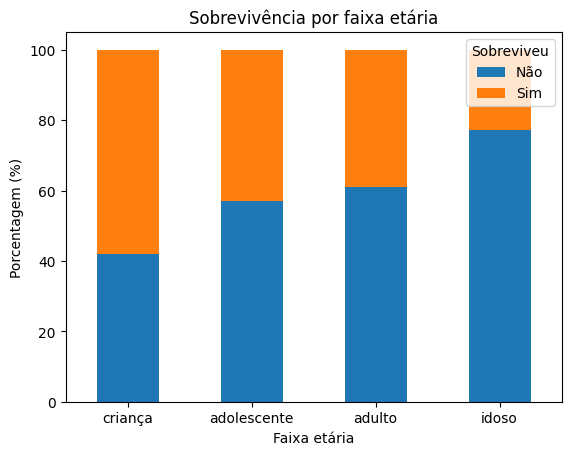

In [487]:
# Relação entre a idade e sobrevivência

df_titanic['faixa_etaria'] = pd.cut(df_titanic['idade'], bins=[0,12,18,60,100],
                           labels=['criança','adolescente','adulto','idoso'])

df_titanic.groupby('faixa_etaria')['sobreviveu'].value_counts(normalize=True).unstack()*100


tabela_idade = df_titanic.groupby('faixa_etaria')['sobreviveu'].value_counts(normalize=True).unstack()*100

import matplotlib.pyplot as plt

tabela_idade.plot(kind='bar', stacked=True)

plt.title('Sobrevivência por faixa etária')
plt.xlabel('Faixa etária')
plt.ylabel('Porcentagem (%)')
plt.legend(title='Sobreviveu')

plt.xticks(rotation=0)

plt.show()


#A análise mostra que a idade teve influência na sobrevivência. Crianças apresentaram maior proporção de sobrevivência em comparação com adultos e idosos, possivelmente devido à prioridade dada a mulheres e crianças durante a evacuação.



/tmp/ipykernel_714/3204599239.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_titanic.groupby('categoria_familia')['sobrevivente'].mean()*100
/tmp/ipykernel_714/3204599239.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tabela_familia = df_titanic.groupby('categoria_familia')['sobrevivente'].mean()*100


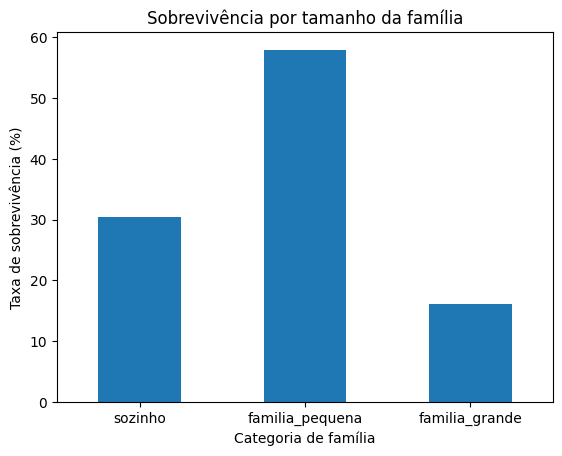

In [488]:
# Relação entre o tamanho da família a bordo e a sobrevivência

df_titanic['categoria_familia'] = pd.cut(
    df_titanic['tamanho_familia'],
    bins=[0,1,4,11],
    labels=['sozinho','familia_pequena','familia_grande']
)

df_titanic.groupby('categoria_familia')['sobrevivente'].mean()*100

tabela_familia = df_titanic.groupby('categoria_familia')['sobrevivente'].mean()*100

import matplotlib.pyplot as plt

tabela_familia.plot(kind='bar')

plt.title('Sobrevivência por tamanho da família')
plt.xlabel('Categoria de família')
plt.ylabel('Taxa de sobrevivência (%)')

plt.xticks(rotation=0)

plt.show()

# A análise indica que o tamanho da família influenciou a sobrevivência. Passageiros que viajavam sozinhos apresentaram menor taxa de sobrevivência, enquanto aqueles em famílias pequenas tiveram maiores chances de sobreviver. Famílias muito grandes também apresentaram menor taxa, possivelmente devido à dificuldade de evacuação conjunta.

/tmp/ipykernel_714/1361321973.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_titanic.groupby('faixa_preco')['sobrevivente'].mean()*100
/tmp/ipykernel_714/1361321973.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tabela_preco = df_titanic.groupby('faixa_preco')['sobrevivente'].mean()*100


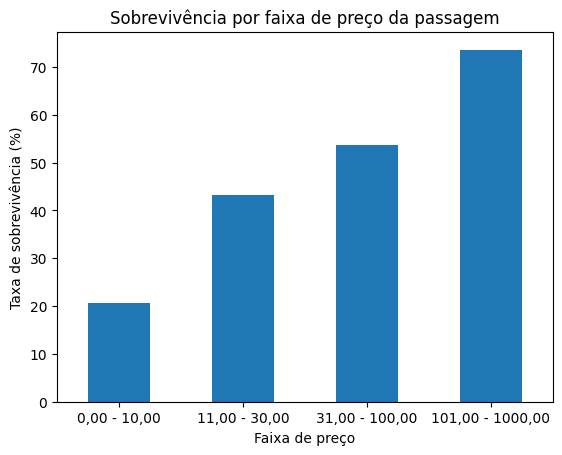

In [489]:
# Relação entre O valor pago pela passagem e sobrevivência

df_titanic['faixa_preco'] = pd.cut(
    df_titanic['preco_passagem'],
    bins=[0,10,30,100,600],
    labels=['0,00 - 10,00','11,00 - 30,00','31,00 - 100,00','101,00 - 1000,00']
)

df_titanic.groupby('faixa_preco')['sobrevivente'].mean()*100

tabela_preco = df_titanic.groupby('faixa_preco')['sobrevivente'].mean()*100

tabela_preco.plot(kind='bar')

plt.title('Sobrevivência por faixa de preço da passagem')
plt.xlabel('Faixa de preço')
plt.ylabel('Taxa de sobrevivência (%)')

plt.xticks(rotation=0)

plt.show()

# A análise indica que passageiros que pagaram passagens mais caras tiveram maior probabilidade de sobreviver. Isso pode estar relacionado à classe social e à localização das cabines no navio.

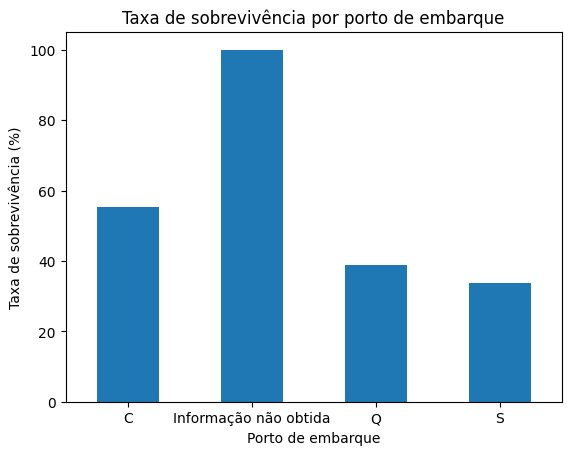

In [490]:
# Relação entre porto de embarque e sobrevivência

df_titanic.groupby('porto_embarque')['sobrevivente'].mean()*100

tabela_porto = df_titanic.groupby('porto_embarque')['sobrevivente'].mean()*100

import matplotlib.pyplot as plt

tabela_porto.plot(kind='bar')

plt.title('Taxa de sobrevivência por porto de embarque')
plt.xlabel('Porto de embarque')
plt.ylabel('Taxa de sobrevivência (%)')

plt.xticks(rotation=0)

plt.show()

# A análise indica que o porto de embarque teve relação com a sobrevivência. Passageiros que embarcaram em Cherbourg apresentaram maior taxa de sobrevivência, enquanto aqueles que embarcaram em Southampton tiveram menor taxa. Essa diferença pode estar relacionada à distribuição das classes sociais entre os portos de embarque.


## Conclusões

A análise exploratória do dataset do Titanic permitiu identificar alguns fatores importantes relacionados à sobrevivência dos passageiros.

Principais insights:

- Mulheres apresentaram taxas de sobrevivência significativamente maiores que homens.
- Passageiros da primeira classe tiveram maiores chances de sobreviver.
- Crianças apresentaram maior probabilidade de sobrevivência em comparação com adultos e idosos.
- Passageiros que viajavam em famílias pequenas tiveram melhores chances de sobreviver do que aqueles que viajavam sozinhos ou em famílias muito grandes.
- Valores mais altos de passagem estão associados a maiores taxas de sobrevivência.
- O porto de embarque também apresentou diferenças nas taxas de sobrevivência, possivelmente relacionadas à distribuição de classes sociais entre os passageiros.

Esses resultados indicam que fatores sociais e estruturais influenciaram fortemente as chances de sobrevivência durante o desastre do Titanic.